#  Notebook 03: Segmented Funnel Analysis

**FlowBoard** — SaaS Product-Led Growth Funnel Analysis

---

## Objective
Break down the funnel by key dimensions to identify **who** is struggling, not just **where** users drop off.

### Segments Analyzed:
1. **Device Type** — Desktop vs Mobile vs Tablet
2. **Acquisition Channel** — Organic vs Paid Ads vs Referral vs Social vs Direct
3. **Geography** — US vs India vs UK vs Germany vs Brazil vs Canada
4. **Signup Cohort** — Week-over-week comparison (monthly cohorts)
5. **Conversion Heatmap** — All segments × all stages

---

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

STAGE_ORDER = {
    'website_visit': 1, 'signup': 2, 'onboarding_complete': 3,
    'first_project_created': 4, 'upgrade_to_paid': 5, 'day_30_active': 6,
}
STAGE_LABELS = {
    'website_visit': 'Website Visit', 'signup': 'Free Trial Signup',
    'onboarding_complete': 'Onboarding Complete',
    'first_project_created': 'First Project (Aha!)',
    'upgrade_to_paid': 'Upgrade to Paid', 'day_30_active': '30-Day Retained',
}
STAGES = sorted(STAGE_ORDER.keys(), key=lambda x: STAGE_ORDER[x])
STAGE_LABEL_LIST = [STAGE_LABELS[s] for s in STAGES]

print('Libraries loaded ✓')

Libraries loaded ✓


In [12]:
# Load cleaned data
events = pd.read_csv('../data/cleaned/clean_events.csv', parse_dates=['event_timestamp'])
users = pd.read_csv('../data/cleaned/clean_users.csv', parse_dates=['signup_date'])

print(f"Events: {len(events):,} | Users: {len(users):,}")

Events: 97,126 | Users: 41,280


In [13]:
def build_segmented_funnel(events_df, segment_col):
    """Build funnel conversion rates grouped by a segment column."""
    # Count unique users per stage per segment
    seg_funnel = (
        events_df.groupby([segment_col, 'event_name'])['user_id']
        .nunique()
        .reset_index()
        .rename(columns={'user_id': 'users', 'event_name': 'stage'})
    )
    seg_funnel['stage_order'] = seg_funnel['stage'].map(STAGE_ORDER)
    seg_funnel['stage_label'] = seg_funnel['stage'].map(STAGE_LABELS)
    seg_funnel = seg_funnel.sort_values([segment_col, 'stage_order'])
    
    # Calculate % of top-of-funnel per segment
    top_of_funnel = seg_funnel[seg_funnel['stage'] == 'website_visit'].set_index(segment_col)['users']
    seg_funnel['pct_of_top'] = seg_funnel.apply(
        lambda row: (row['users'] / top_of_funnel.get(row[segment_col], 1) * 100), axis=1
    ).round(2)
    
    return seg_funnel


def plot_segmented_funnel(seg_funnel, segment_col, title, palette=None):
    """Create grouped bar chart for segmented funnel."""
    pivot = seg_funnel.pivot_table(
        index='stage_label', columns=segment_col, values='pct_of_top'
    )
    # Reorder stages
    pivot = pivot.reindex(STAGE_LABEL_LIST)
    
    ax = pivot.plot(kind='bar', figsize=(14, 7), width=0.8, edgecolor='white',
                    colormap=palette or 'viridis', alpha=0.85)
    
    ax.set_ylabel('% of Top-of-Funnel (per segment)', fontsize=13)
    ax.set_xlabel('')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.legend(title=segment_col, fontsize=10, title_fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    plt.tight_layout()
    return ax

## 1.  Funnel by Device Type

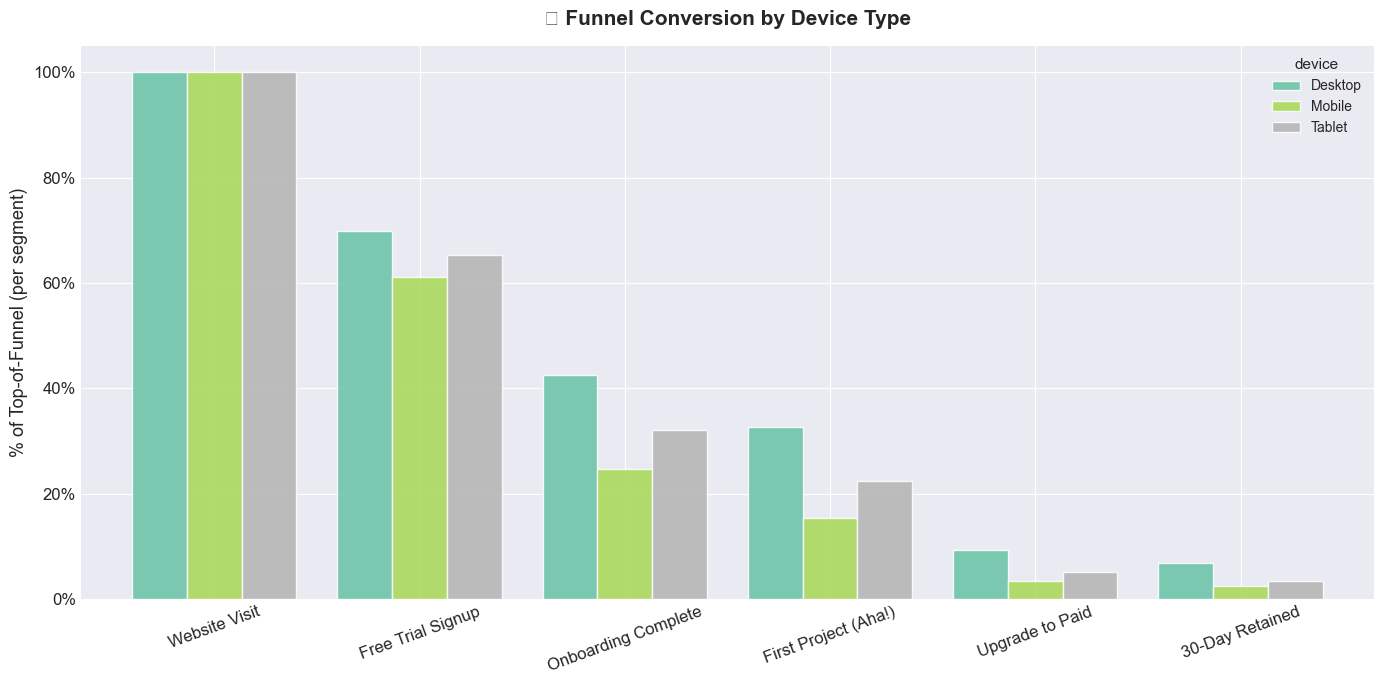


 KEY INSIGHT:
   Desktop onboarding completion: 42.5%
   Mobile onboarding completion:  24.6%
   → Mobile users are 1.7x less likely to complete onboarding


In [14]:
device_funnel = build_segmented_funnel(events, 'device')

ax = plot_segmented_funnel(device_funnel, 'device', 
                           '📱 Funnel Conversion by Device Type', 'Set2')
plt.savefig('../visuals/funnel_by_device.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
device_pivot = device_funnel.pivot_table(index='stage', columns='device', values='pct_of_top')
onboarding_desktop = device_pivot.loc['onboarding_complete', 'Desktop']
onboarding_mobile = device_pivot.loc['onboarding_complete', 'Mobile']
print(f"\n KEY INSIGHT:")
print(f"   Desktop onboarding completion: {onboarding_desktop:.1f}%")
print(f"   Mobile onboarding completion:  {onboarding_mobile:.1f}%")
print(f"   → Mobile users are {onboarding_desktop/onboarding_mobile:.1f}x less likely to complete onboarding")

## 2.  Funnel by Acquisition Channel

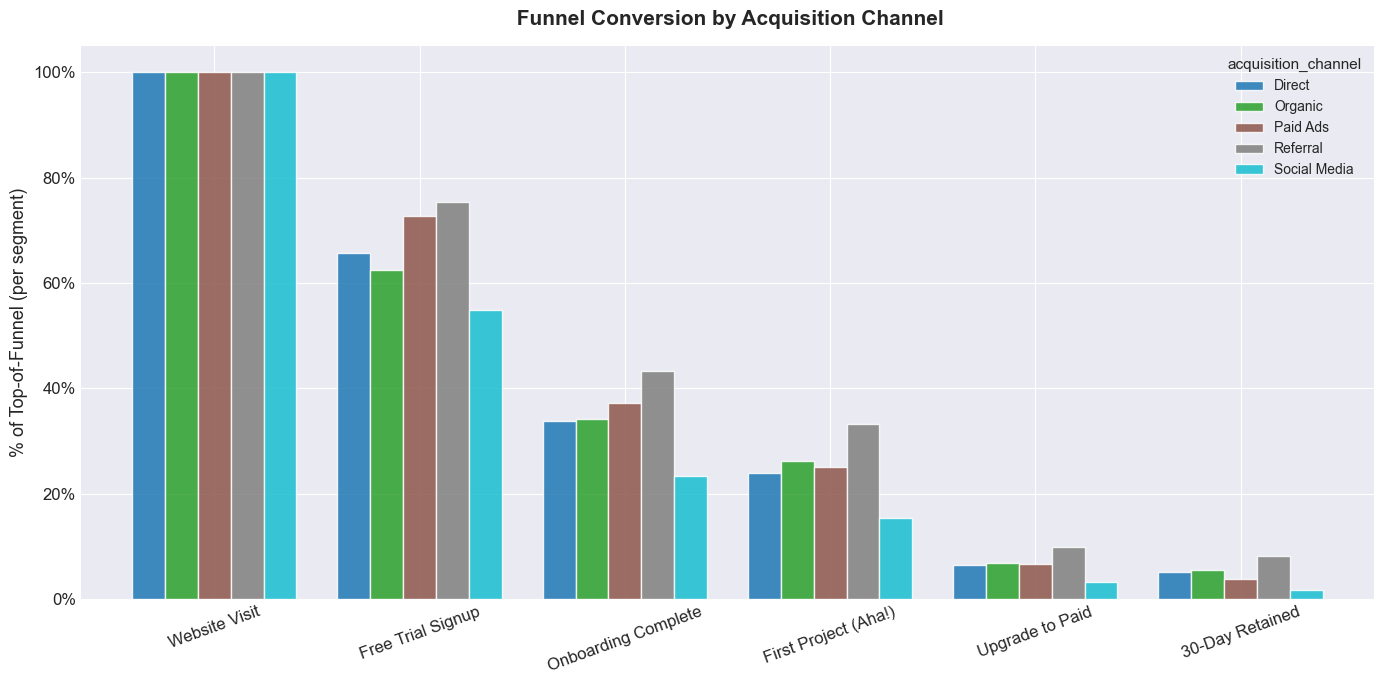


 KEY INSIGHT:
   Paid Ads → 30-Day Retention:  3.82%
   Referral → 30-Day Retention:  8.27%
   → Referral users retain 2.2x better than Paid Ads


In [15]:
channel_funnel = build_segmented_funnel(events, 'acquisition_channel')

ax = plot_segmented_funnel(channel_funnel, 'acquisition_channel',
                           ' Funnel Conversion by Acquisition Channel', 'tab10')
plt.savefig('../visuals/funnel_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight: Paid ads retention
channel_pivot = channel_funnel.pivot_table(index='stage', columns='acquisition_channel', values='pct_of_top')
if 'day_30_active' in channel_pivot.index:
    retention_paid = channel_pivot.loc['day_30_active', 'Paid Ads']
    retention_referral = channel_pivot.loc['day_30_active', 'Referral']
    print(f"\n KEY INSIGHT:")
    print(f"   Paid Ads → 30-Day Retention:  {retention_paid:.2f}%")
    print(f"   Referral → 30-Day Retention:  {retention_referral:.2f}%")
    print(f"   → Referral users retain {retention_referral/max(retention_paid,0.01):.1f}x better than Paid Ads")

## 3.  Funnel by Geography

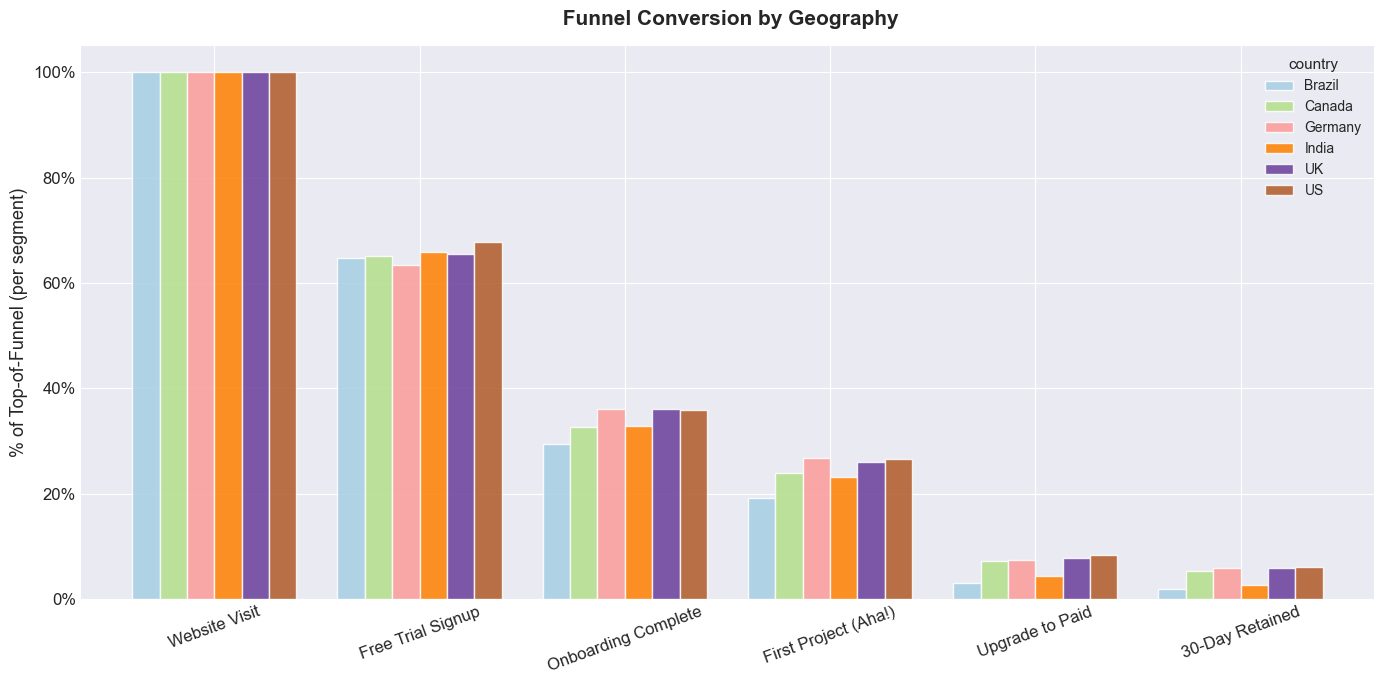


 KEY INSIGHT — Payment Friction:
   US upgrade rate:     8.34%
   India upgrade rate:  4.47%
   Brazil upgrade rate: 3.06%
   → India/Brazil show significant payment friction (likely payment method limitations)


In [16]:
geo_funnel = build_segmented_funnel(events, 'country')

ax = plot_segmented_funnel(geo_funnel, 'country',
                           ' Funnel Conversion by Geography', 'Paired')
plt.savefig('../visuals/funnel_by_geography.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight: Payment friction
geo_pivot = geo_funnel.pivot_table(index='stage', columns='country', values='pct_of_top')
if 'upgrade_to_paid' in geo_pivot.index:
    upgrade_us = geo_pivot.loc['upgrade_to_paid', 'US']
    upgrade_india = geo_pivot.loc['upgrade_to_paid', 'India']
    upgrade_brazil = geo_pivot.loc['upgrade_to_paid', 'Brazil']
    print(f"\n KEY INSIGHT — Payment Friction:")
    print(f"   US upgrade rate:     {upgrade_us:.2f}%")
    print(f"   India upgrade rate:  {upgrade_india:.2f}%")
    print(f"   Brazil upgrade rate: {upgrade_brazil:.2f}%")
    print(f"   → India/Brazil show significant payment friction (likely payment method limitations)")

## 4.  Funnel by Signup Cohort (Monthly)

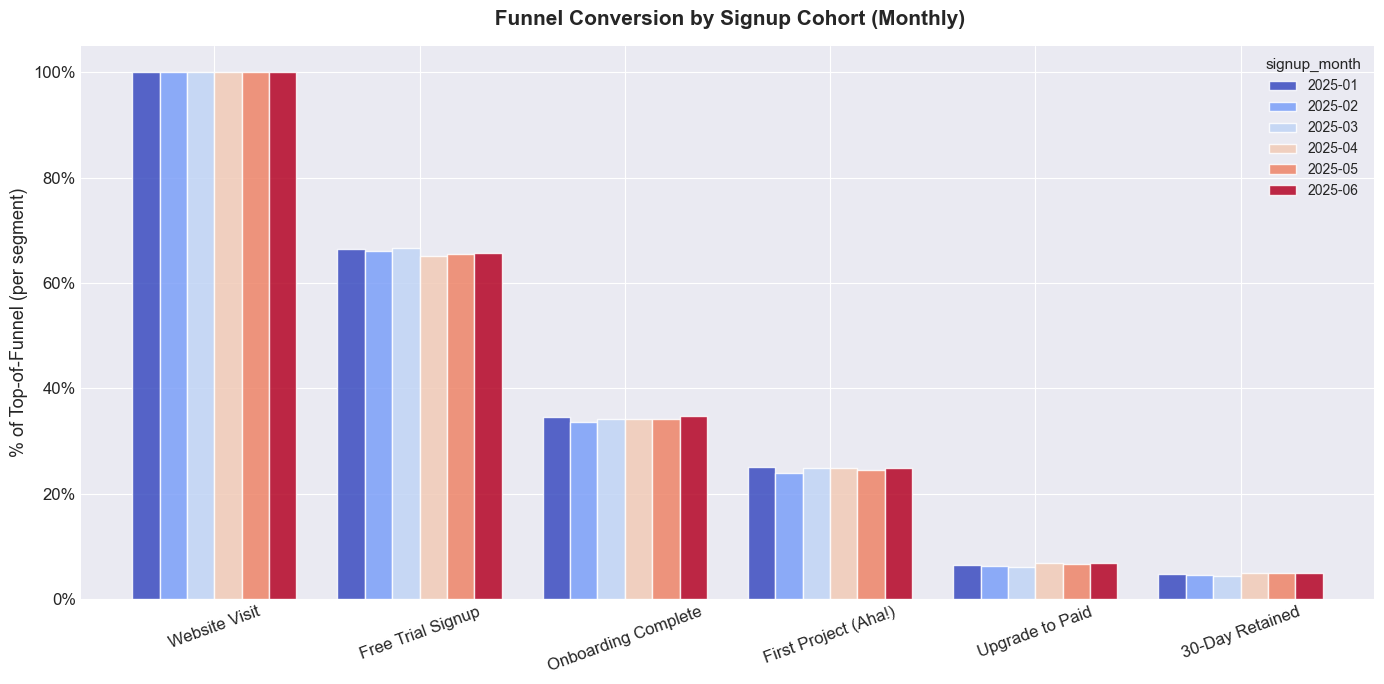


 KEY INSIGHT: Compare how later cohorts perform vs earlier ones
   → Improvements in later months suggest product iteration is working
   → Declines may indicate market saturation or seasonal effects


In [17]:
# Create monthly cohort column
events_with_cohort = events.merge(
    users[['user_id', 'signup_date']], on='user_id', how='left'
)
events_with_cohort['signup_month'] = events_with_cohort['signup_date'].dt.to_period('M').astype(str)

cohort_funnel = build_segmented_funnel(events_with_cohort, 'signup_month')

ax = plot_segmented_funnel(cohort_funnel, 'signup_month',
                           ' Funnel Conversion by Signup Cohort (Monthly)', 'coolwarm')
plt.savefig('../visuals/funnel_by_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n KEY INSIGHT: Compare how later cohorts perform vs earlier ones")
print("   → Improvements in later months suggest product iteration is working")
print("   → Declines may indicate market saturation or seasonal effects")

## 5.  Conversion Heatmap — All Segments × All Stages

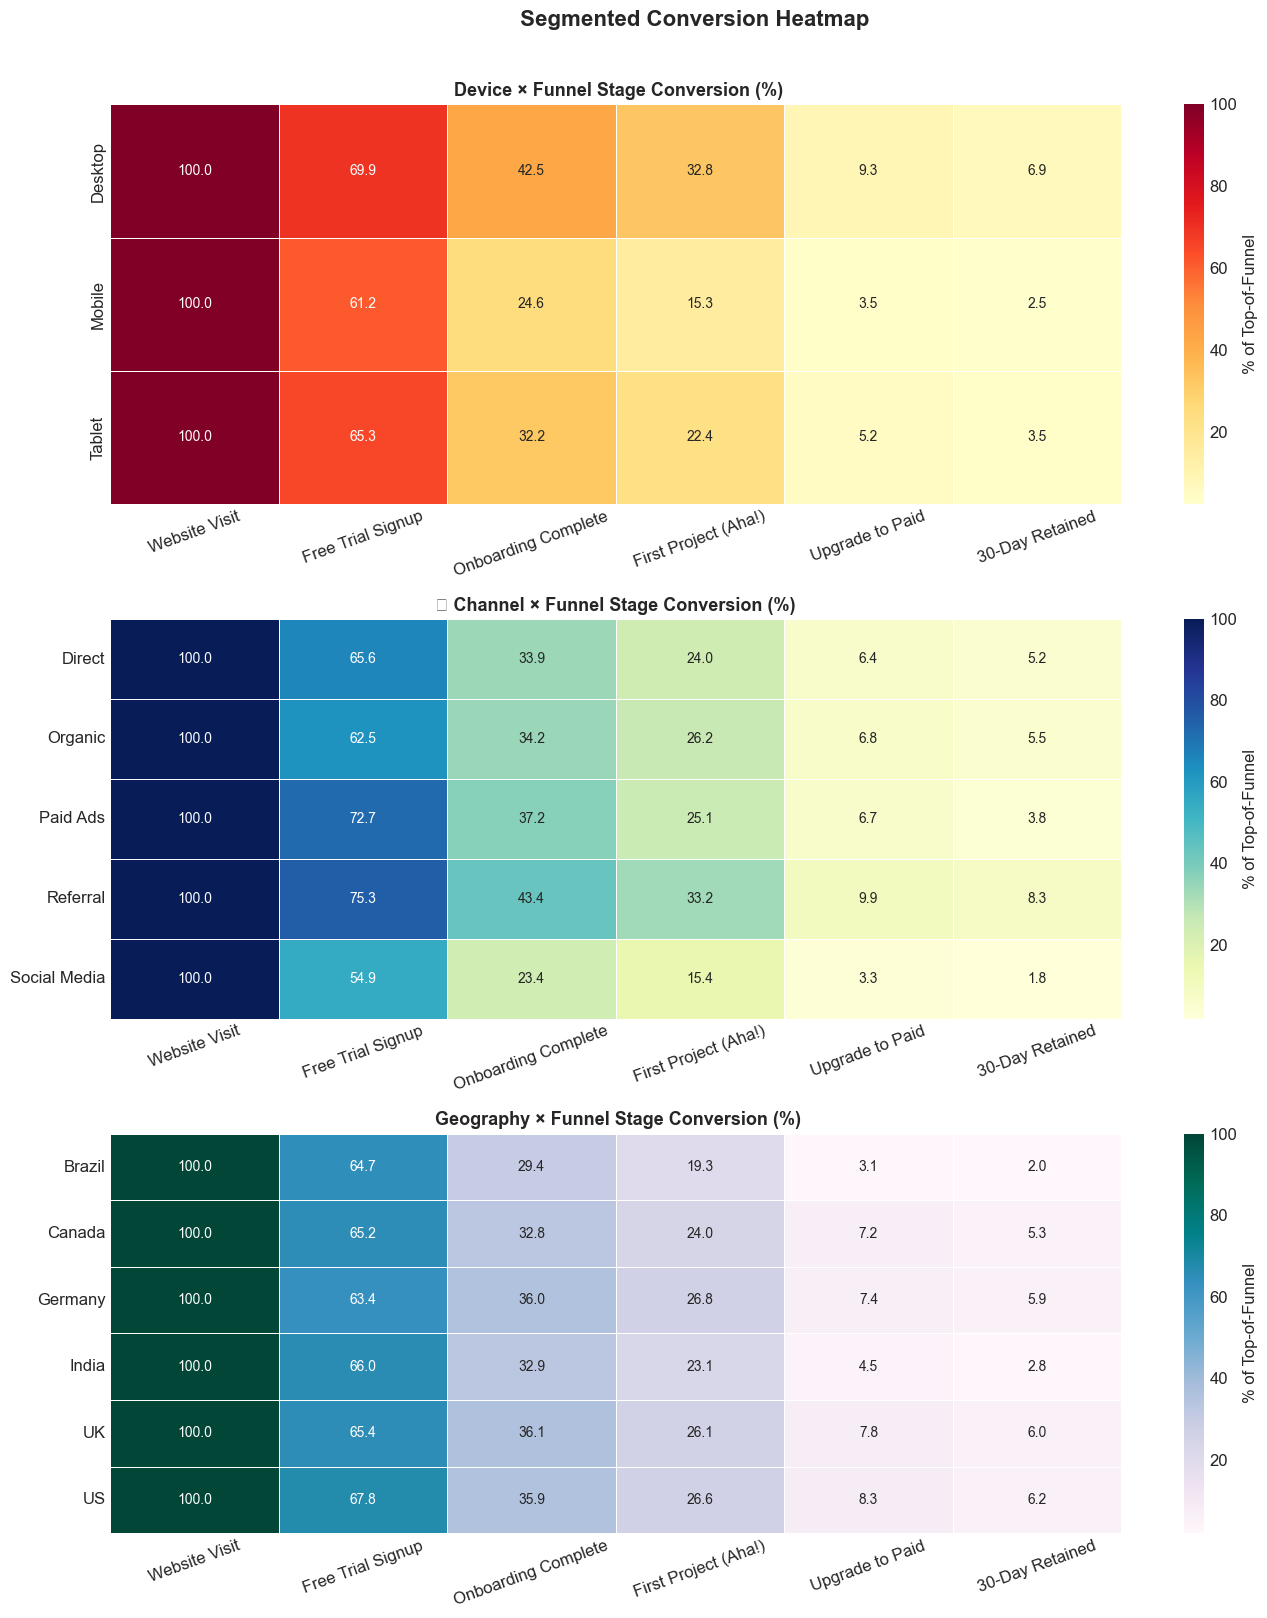

✓ Saved to visuals/segmented_heatmap.png


In [18]:
# Build heatmap data: Device × Stage conversion rates
def build_heatmap_data(events_df, segment_col):
    seg_funnel = build_segmented_funnel(events_df, segment_col)
    return seg_funnel.pivot_table(
        index=segment_col, columns='stage_label', values='pct_of_top'
    ).reindex(columns=STAGE_LABEL_LIST)

# Create multi-segment heatmap
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

segments = [
    ('device', ' Device', 'YlOrRd'),
    ('acquisition_channel', '📣 Channel', 'YlGnBu'),
    ('country', ' Geography', 'PuBuGn'),
]

for ax, (col, title, cmap) in zip(axes, segments):
    heatmap_data = build_heatmap_data(events, col)
    sns.heatmap(
        heatmap_data, annot=True, fmt='.1f', cmap=cmap,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'label': '% of Top-of-Funnel'},
        annot_kws={'fontsize': 10}
    )
    ax.set_title(f'{title} × Funnel Stage Conversion (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(' Segmented Conversion Heatmap', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../visuals/segmented_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to visuals/segmented_heatmap.png")

## 6. Key Findings Summary

In [19]:

print("  SEGMENTED ANALYSIS — KEY FINDINGS")

print(f"""
  1. DEVICE: Mobile users struggle significantly at onboarding.
     → Recommendation: Simplify mobile onboarding flow, reduce form fields

  2. CHANNEL: Paid Ads drive signups but have the worst retention.
     → Recommendation: Shift budget toward Referral programs which show
       the highest lifetime value

  3. GEOGRAPHY: India & Brazil show severe payment friction.
     → Recommendation: Add local payment methods (UPI for India, 
       PIX for Brazil) and consider regional pricing

  4. COHORTS: Track month-over-month to measure product improvements.
     → Recommendation: Set up automated cohort dashboards for ongoing monitoring
""")


  SEGMENTED ANALYSIS — KEY FINDINGS

  1. DEVICE: Mobile users struggle significantly at onboarding.
     → Recommendation: Simplify mobile onboarding flow, reduce form fields

  2. CHANNEL: Paid Ads drive signups but have the worst retention.
     → Recommendation: Shift budget toward Referral programs which show
       the highest lifetime value

  3. GEOGRAPHY: India & Brazil show severe payment friction.
     → Recommendation: Add local payment methods (UPI for India, 
       PIX for Brazil) and consider regional pricing

  4. COHORTS: Track month-over-month to measure product improvements.
     → Recommendation: Set up automated cohort dashboards for ongoing monitoring

